## EXPLORATORY DATA ANALYSIS & DATA VISUALIZATION

#### HISTOGRAM

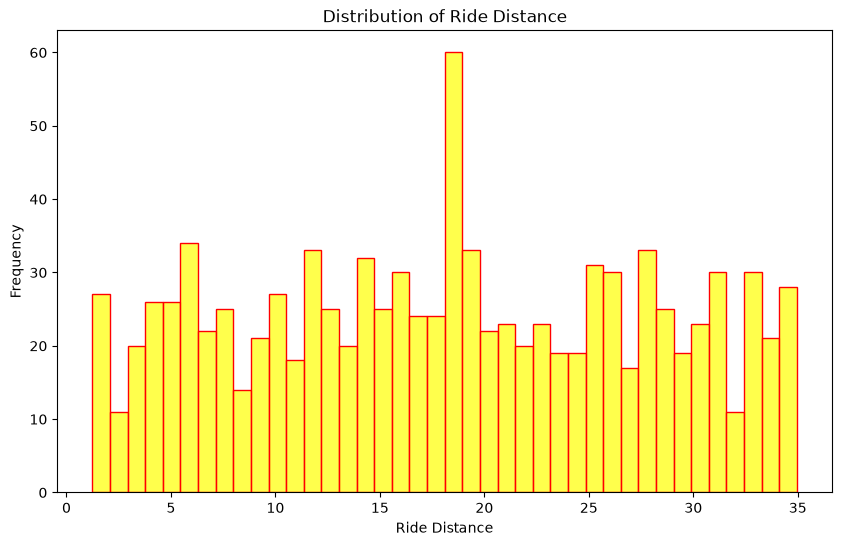

In [52]:
#Figure size
plt.figure(figsize=(10,6))

#Plotting histogram for 'Ride Distance'
sns.histplot(uber_df['Ride Distance'] , 
             bins =40, 
             color ='yellow',
             edgecolor ='red',
             alpha =0.7
            )

#Adding X & Y labels to the plot
plt.xlabel('Ride Distance')
plt.ylabel('Frequency')

#Adding title to the plot
plt.title('Distribution of Ride Distance')

#To display graph
plt.show()


#### PICKUP & DROP LOCATIONS

In [53]:
uber_df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'waiting time',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method', 'Year', 'Month',
       'Month_Name', 'Day', 'Day_of_week', 'Is_Weekend', 'Hour', 'Day-Night',
       'Peak_Hour'],
      dtype='str')

In [63]:
#To find unique pickup locations
print(uber_df['Pickup Location'].unique())
print()

#To display number of unique pickup locations
print("Total number of unique pickup locations: ")
print(uber_df['Pickup Location'].nunique())

<StringArray>
[    'Toronto', 'Los Angeles',   'Melbourne',  'Birmingham',       'Paris',
      'Sydney',       'Tokyo',   'Vancouver',     'Phoenix',       'Dubai',
    'New York',      'Madrid',      'Berlin',       'Seoul',      'London',
        'Rome',     'Houston',     'Chicago',  'Manchester',   'Singapore']
Length: 20, dtype: str

Total number of unique pickup locations: 
20


In [64]:
#To find unique drop locations
print(uber_df['Drop Location'].unique())
print()

#To display number of unique drop locations
print("Total number of unique drop locations: ")
print(uber_df['Drop Location'].nunique())

<StringArray>
[  'Melbourne',      'Madrid',       'Dubai',  'Manchester',     'Chicago',
        'Rome',    'New York',      'Berlin',   'Singapore',     'Houston',
     'Toronto',   'Vancouver',     'Phoenix',       'Paris',       'Seoul',
      'Sydney',      'London', 'Los Angeles',       'Tokyo',  'Birmingham']
Length: 20, dtype: str

Total number of unique drop locations: 
20


In [65]:
#How many we have in each unique starting points.
uber_df['Pickup Location'].value_counts().head(10)

Pickup Location
Toronto        80
Birmingham     57
Berlin         55
Singapore      54
Sydney         53
Dubai          53
New York       51
Phoenix        50
Los Angeles    49
Seoul          49
Name: count, dtype: int64

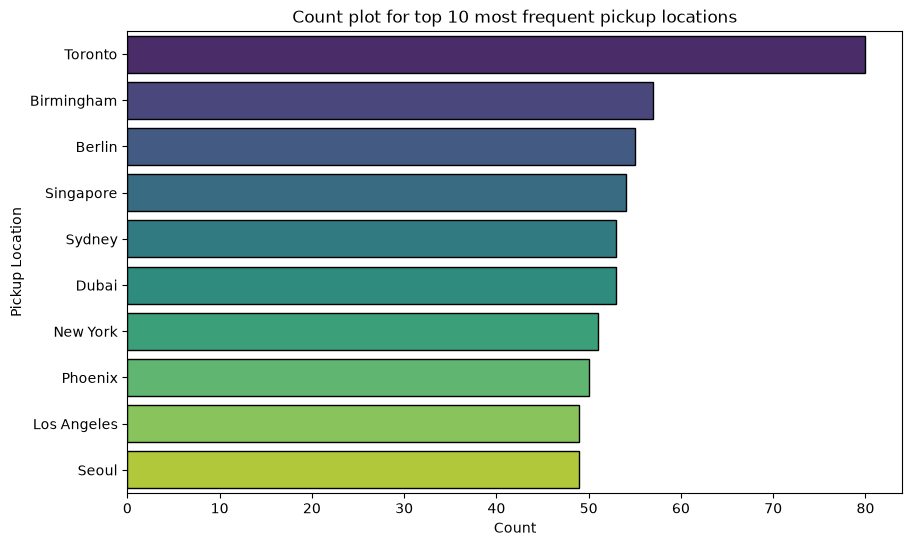

In [70]:
#Plotting it using a count plot.

#Figure size
plt.figure(figsize=(10,6))

#To create a horizontal count plot showing the top 10 most frequent Pickup Locations
sns.countplot(y='Pickup Location',
              order =uber_df['Pickup Location'].value_counts().iloc[:10].index,
              data=uber_df,
              palette ='viridis',
              edgecolor= 'black')

#Adding x & y label to the plot with title
plt.xlabel('Count')
plt.ylabel('Pickup Location')
plt.title('Count plot for top 10 most frequent pickup locations')

#To display the plot
plt.show()


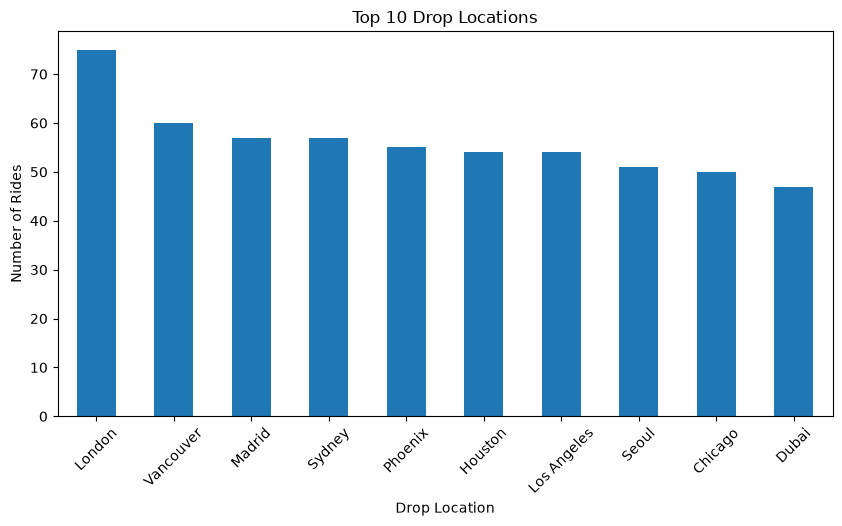

In [71]:
#To Visualize top 10 drop locations
uber_df['Drop Location'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10, 5)
)

#Adding title and labes to the plot
plt.title('Top 10 Drop Locations')
plt.xlabel('Drop Location')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)
plt.show()

#### PEAK HOUR ANALYSIS

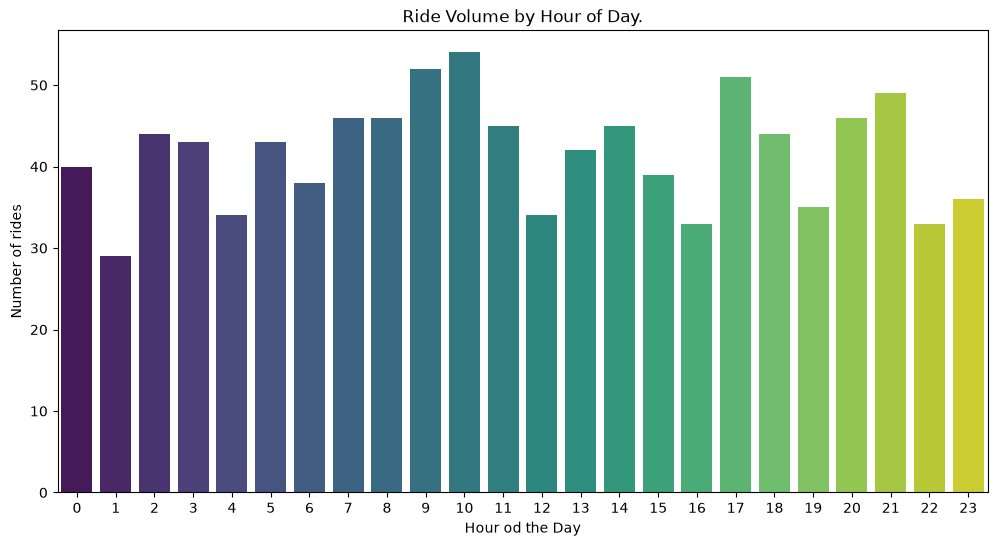

Peak Hour: 10:00 with 54 rides


In [75]:
#Figure size
plt.figure(figsize=(12,6))

#Peak-hour analysis
hourly_rides = uber_df['Hour'].value_counts().sort_index()

#Plotting  bar plot
sns.barplot(x=hourly_rides.index, 
            y=hourly_rides.values,
            palette ='viridis'
           )

#Addin X and Y labels to the plot
plt.xlabel("Hour od the Day")
plt.ylabel("Number of rides")

#Adding title
plt.title("Ride Volume by Hour of Day.")

plt.show()

#TO print the peak hour
peak_hour =hourly_rides.idxmax()
print(f"Peak Hour: {peak_hour}:00 with {hourly_rides.max()} rides")

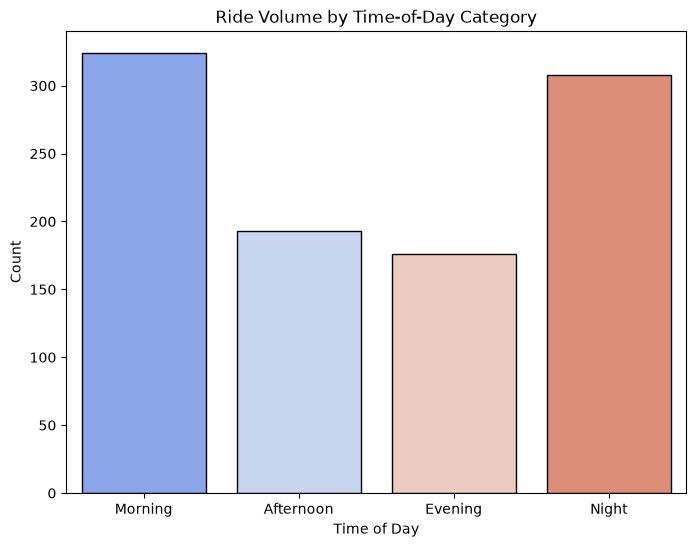

In [81]:
# Ride volume by day-night bucket
plt.figure(figsize=(8, 6))

sns.countplot(x='Day-Night', 
              data=uber_df, 
               order=['Morning', 'Afternoon', 'Evening', 'Night'],
              palette='coolwarm', 
              edgecolor='black')

plt.xlabel('Time of Day')
plt.ylabel('Count')

plt.title('Ride Volume by Time-of-Day Category')
plt.show()


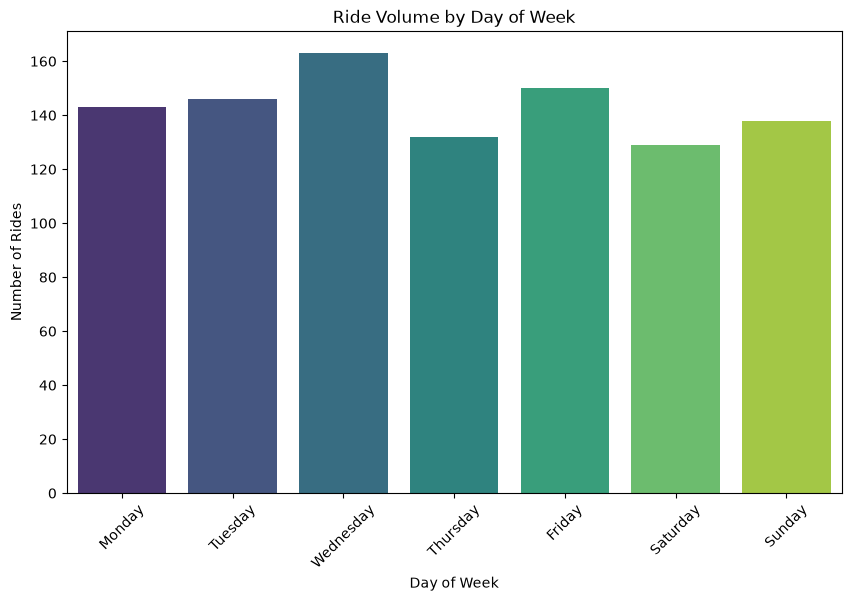

In [90]:
# Ride volume by day of week
plt.figure(figsize=(10, 6))

day_order = ['Monday', 'Tuesday', 'Wednesday', 
             'Thursday', 'Friday', 'Saturday', 'Sunday']

sns.countplot(x='Day_of_week', 
              data=uber_df, 
              order=day_order, 
              palette='viridis')

plt.xlabel('Day of Week')
plt.ylabel('Number of Rides')
plt.title('Ride Volume by Day of Week')
plt.xticks(rotation=45)
plt.show()


#### PRICING TRENDS

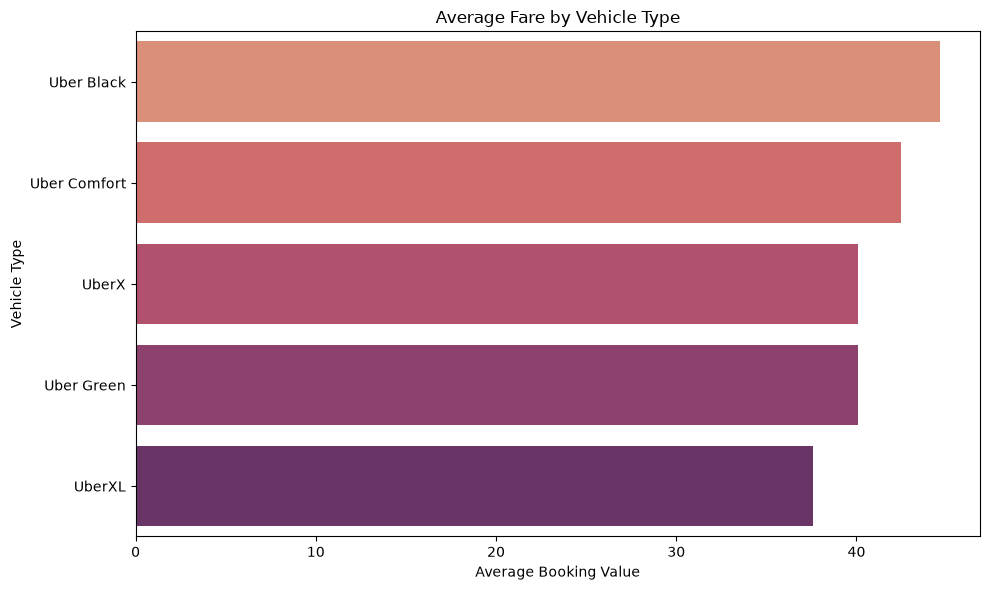

In [91]:
# Average booking value by vehicle type
plt.figure(figsize=(10, 6))

avg_fare_by_vehicle = uber_df.groupby('Vehicle Type')['Booking Value'].mean().sort_values(ascending=False)

sns.barplot(x=avg_fare_by_vehicle.values, 
            y=avg_fare_by_vehicle.index,
            palette='flare')

plt.xlabel('Average Booking Value')
plt.ylabel('Vehicle Type')

plt.title('Average Fare by Vehicle Type')
plt.tight_layout()
plt.show()

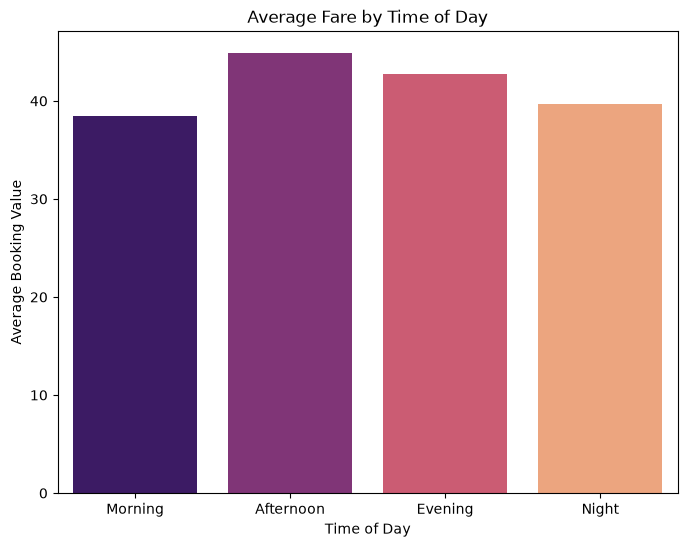

In [92]:
# Average booking value by time of day
plt.figure(figsize=(8, 6))

avg_fare_by_time = uber_df.groupby('Day-Night')['Booking Value'].mean().reindex(['Morning', 'Afternoon', 'Evening', 'Night'])

sns.barplot(x=avg_fare_by_time.index, 
            y=avg_fare_by_time.values, 
            palette='magma')

plt.xlabel('Time of Day')
plt.ylabel('Average Booking Value')

plt.title('Average Fare by Time of Day')
plt.show()

#### CORRELATION ANALYSIS

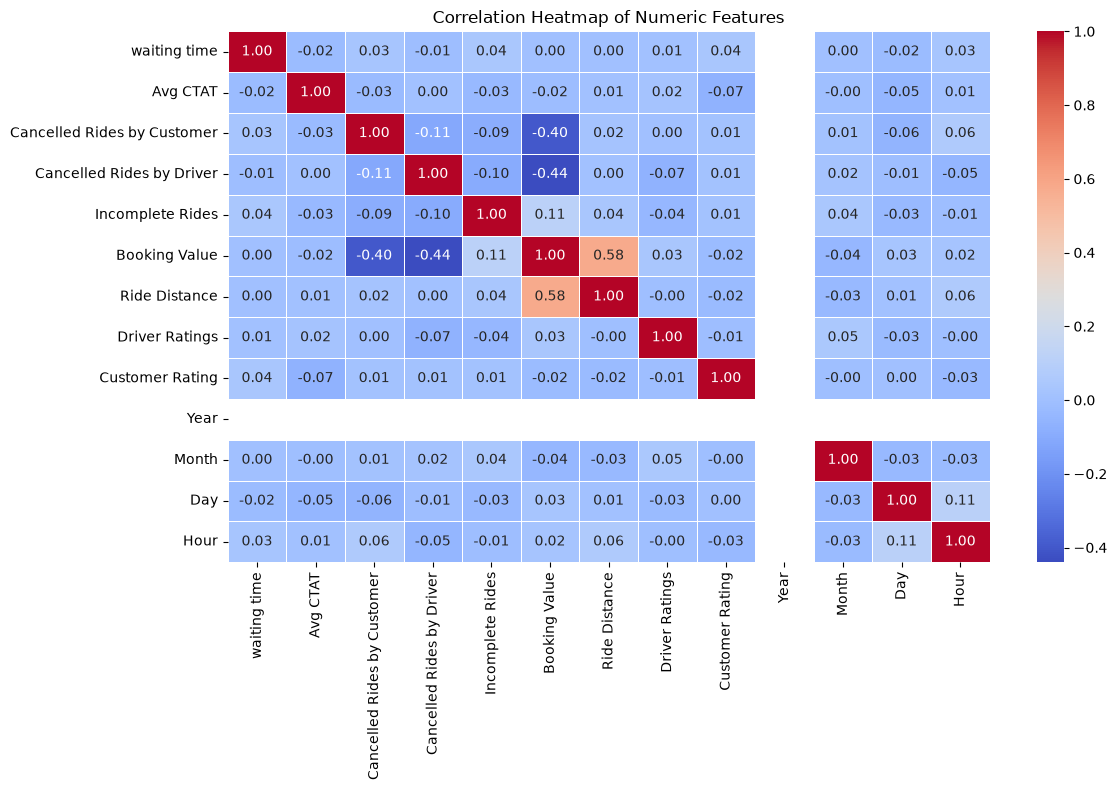

In [93]:
# Correlation heatmap across numeric columns
numeric_df = uber_df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))

corr = numeric_df.corr()

sns.heatmap(corr, annot=True, 
            cmap='coolwarm', 
            fmt='.2f', 
            linewidths=0.5)

plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()


#### CANCELLATION ANALYSIS

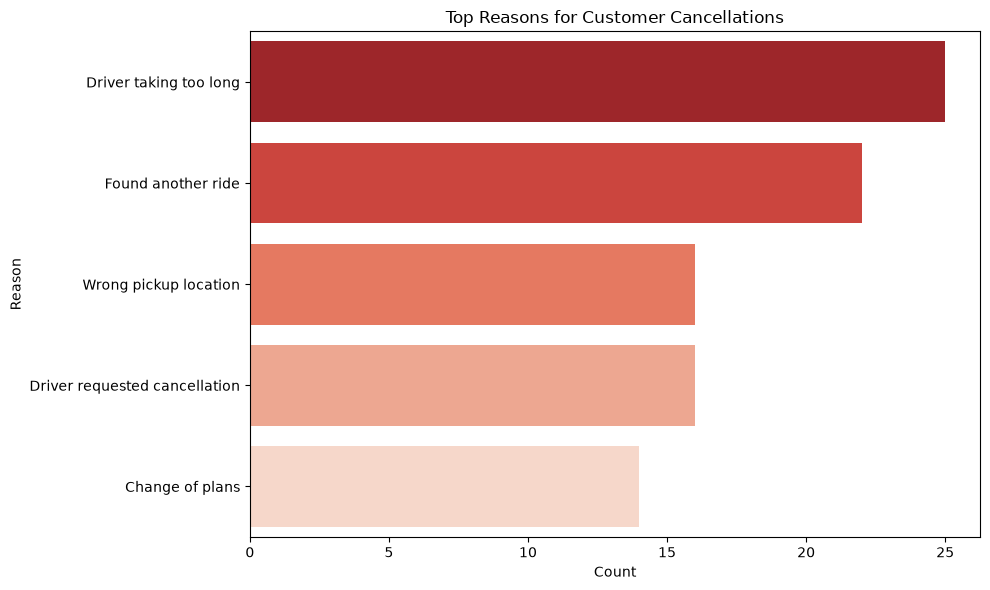

In [94]:
# Top reasons for customer cancellations (excluding 'Not Applicable')
customer_reasons = uber_df.loc[uber_df['Reason for cancelling by Customer'] != 'Not Applicable',
    'Reason for cancelling by Customer'].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(x=customer_reasons.values, 
            y=customer_reasons.index, 
            palette='Reds_r')

plt.xlabel('Count')
plt.ylabel('Reason')

plt.title('Top Reasons for Customer Cancellations')
plt.tight_layout()
plt.show()

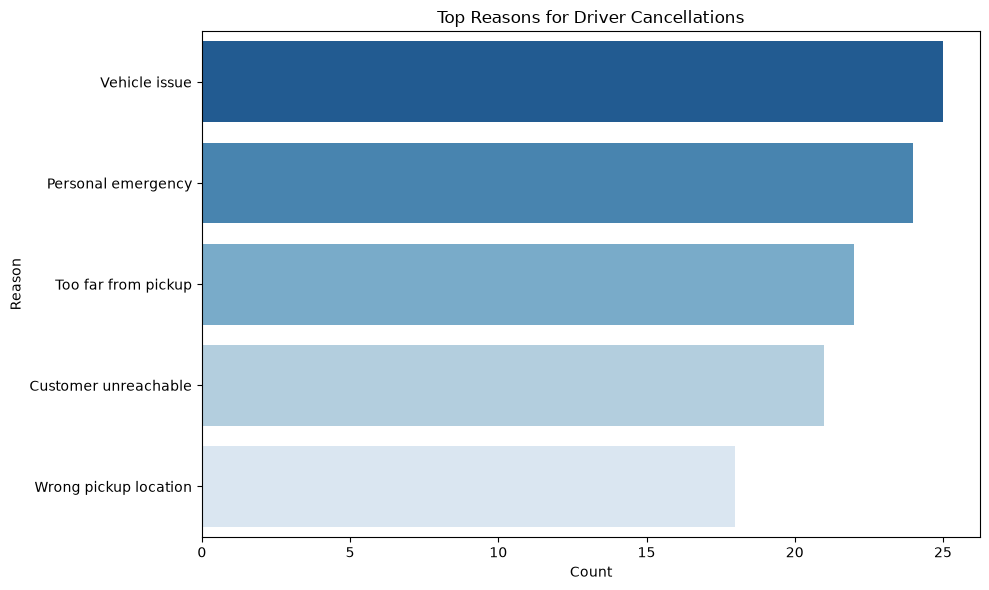

In [95]:
# Top reasons for driver cancellations (excluding 'Not Applicable')
driver_reasons = uber_df.loc[uber_df['Driver Cancellation Reason'] != 'Not Applicable',
    'Driver Cancellation Reason'].value_counts()

plt.figure(figsize=(10, 6))

sns.barplot(x=driver_reasons.values,
            y=driver_reasons.index,
            palette='Blues_r')

plt.xlabel('Count')
plt.ylabel('Reason')

plt.title('Top Reasons for Driver Cancellations')
plt.tight_layout()
plt.show()

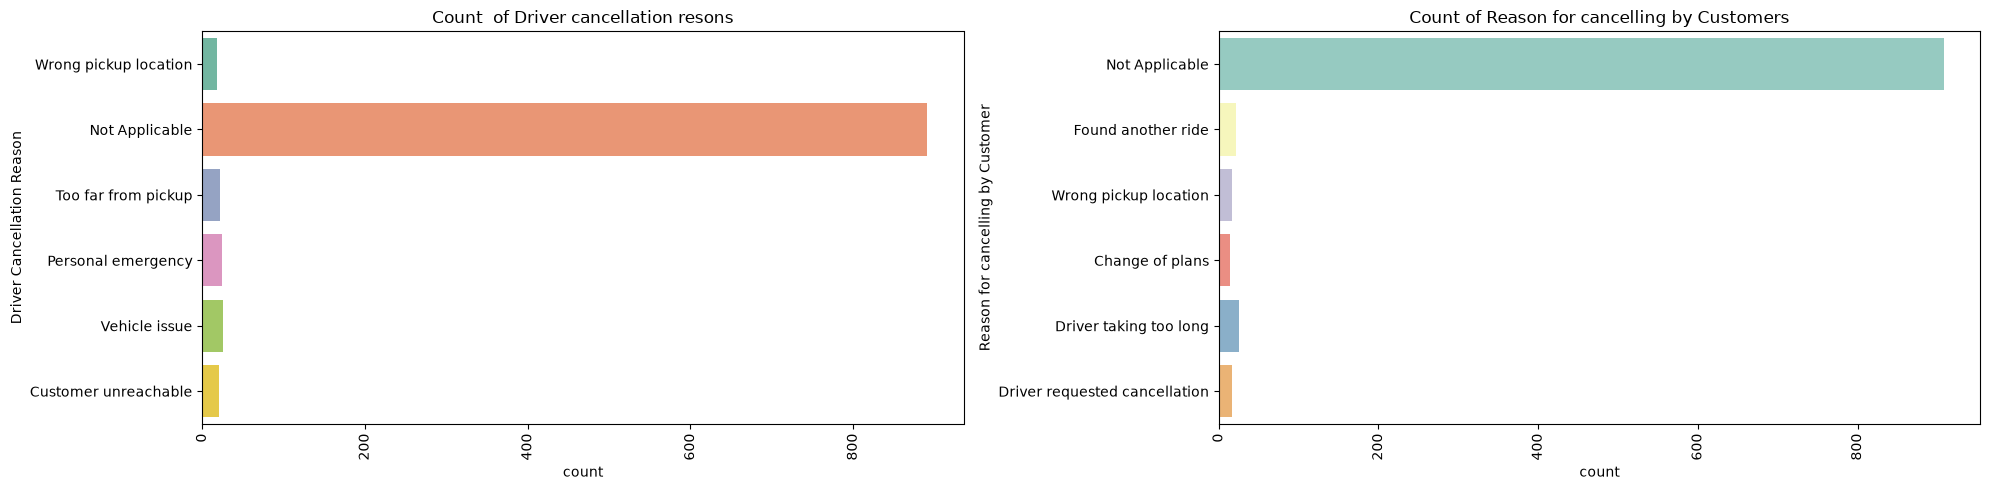

In [97]:
#To plot this as a graph
#Figure size
plt.figure(figsize=(20,5))

#Subplot 1
#In subplot 1st argument->no of rows, 2nd argument->no. of columns, last argument->1 or 2 : selects the position of the plot.
plt.subplot(1,2,1)

#Count plot for the column :Driver Cancellation Reason
sns.countplot(uber_df['Driver Cancellation Reason'],palette = 'Set2')

#Rotate the x axix label to 90 degree to prevent overlap (especially when the labels are long)
plt.xticks(rotation=90)

#Adding title
plt.title("Count  of Driver cancellation resons")

#Subplot 2
plt.subplot(1,2,2)

#Count plot for the column :Reason for cancelling by Customer
sns.countplot(uber_df['Reason for cancelling by Customer'],palette = 'Set3')

#Rotate the x axix label to 90 degree to prevent overlap(especially when the labels are long)
plt.xticks(rotation=90)

#Adding title
plt.title("Count of Reason for cancelling by Customers")

#Providing tight layout : automatically adjusting the layout
plt.tight_layout()

#To display the plot
plt.show()

#### PAYMENT METHOD ANALYSIS

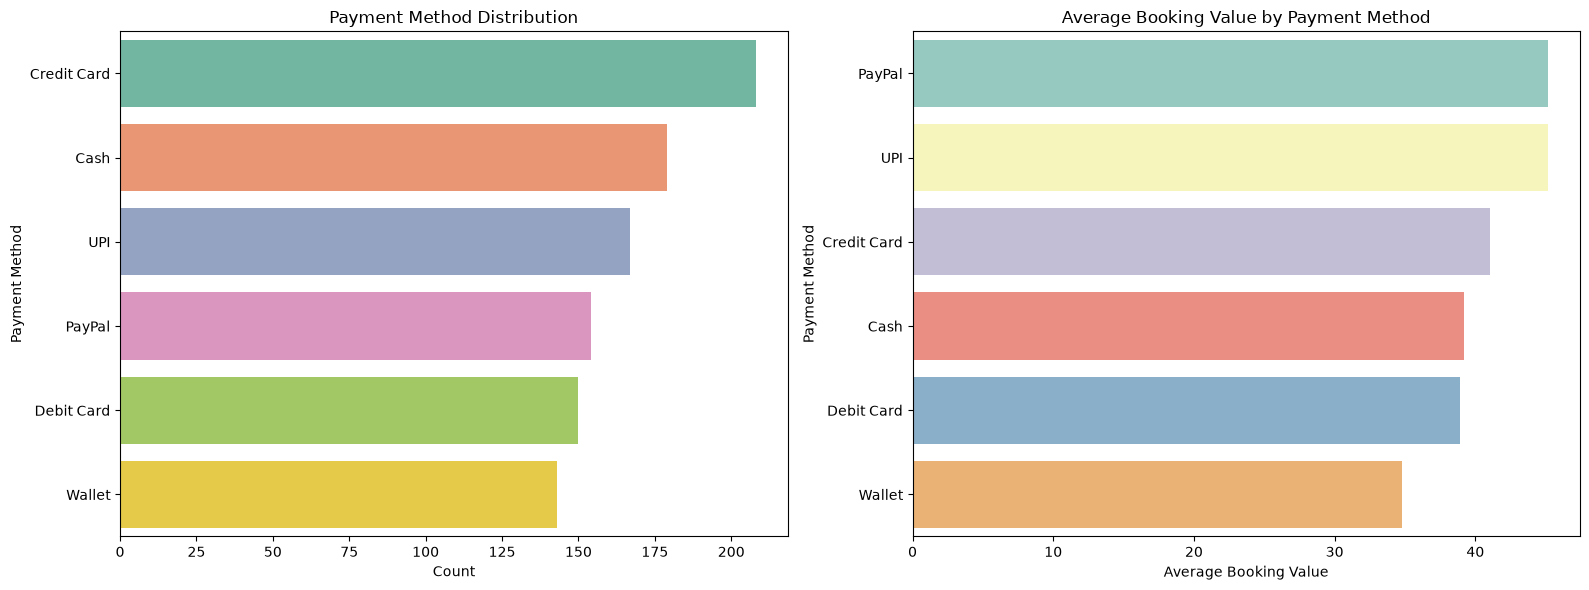

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of payment methods
sns.countplot(y='Payment Method', 
              data=uber_df, 
              order=uber_df['Payment Method'].value_counts().index, 
              palette='Set2', 
              ax=axes[0])

axes[0].set_title('Payment Method Distribution')
axes[0].set_xlabel('Count')

# Average booking value by payment method
avg_by_payment = uber_df.groupby('Payment Method')['Booking Value'].mean().sort_values(ascending=False)

sns.barplot(x=avg_by_payment.values,
            y=avg_by_payment.index, 
            palette='Set3', 
            ax=axes[1])

axes[1].set_title('Average Booking Value by Payment Method')
axes[1].set_xlabel('Average Booking Value')

plt.tight_layout()
plt.show()


#### BOOKING STATUS ANALYSIS

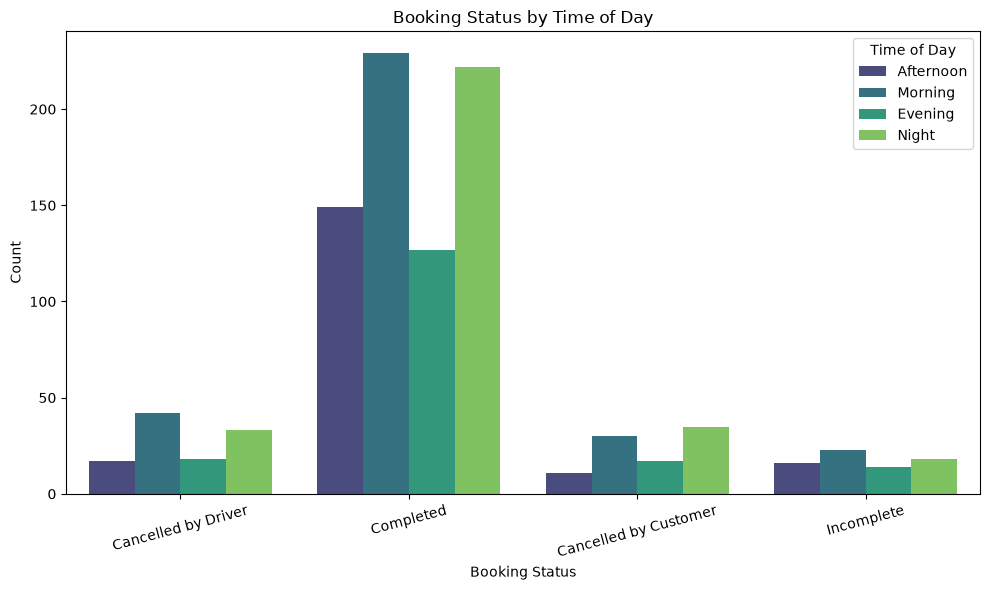

In [100]:
#COUNT PLOT FOR ANALYSING BOOKING STATUS BASED OF DAY_NIGTH CATEGORY

plt.figure(figsize=(10, 6))

sns.countplot(data=uber_df,
              x='Booking Status',
              hue='Day-Night', 
              palette='viridis')

plt.xticks(rotation=15)

plt.title('Booking Status by Time of Day')
plt.xlabel('Booking Status')
plt.ylabel('Count')

plt.legend(title='Time of Day')

plt.tight_layout()
plt.show()

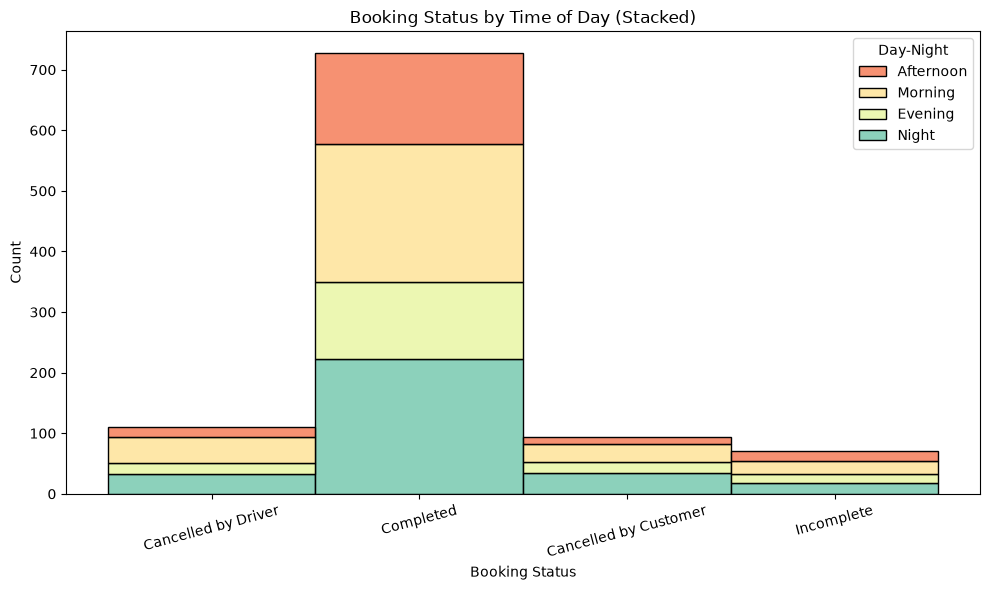

In [101]:
#STACKED BAR PLOT for analysing booking status based on day-night category

plt.figure(figsize=(10, 6))
sns.histplot(data=uber_df,
             x='Booking Status'
             , hue='Day-Night', 
             multiple='stack', 
             palette='Spectral')

plt.xticks(rotation=15)

plt.title('Booking Status by Time of Day (Stacked)')
plt.xlabel('Booking Status')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

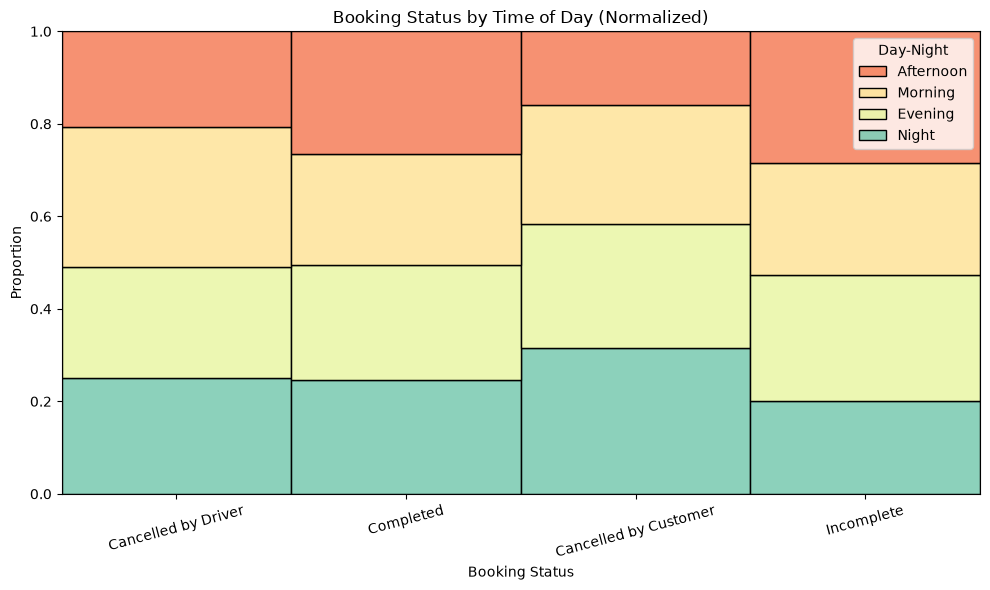

In [102]:
#NORMALIZED STACKED BAR PLOT 
plt.figure(figsize=(10, 6))

sns.histplot(data=uber_df, 
             x='Booking Status',
             hue='Day-Night', 
             stat='probability', 
             common_norm=False, 
             multiple='fill', 
             palette='Spectral')

plt.xticks(rotation=15)

plt.title('Booking Status by Time of Day (Normalized)')
plt.xlabel('Booking Status')
plt.ylabel('Proportion')

plt.tight_layout()
plt.show()


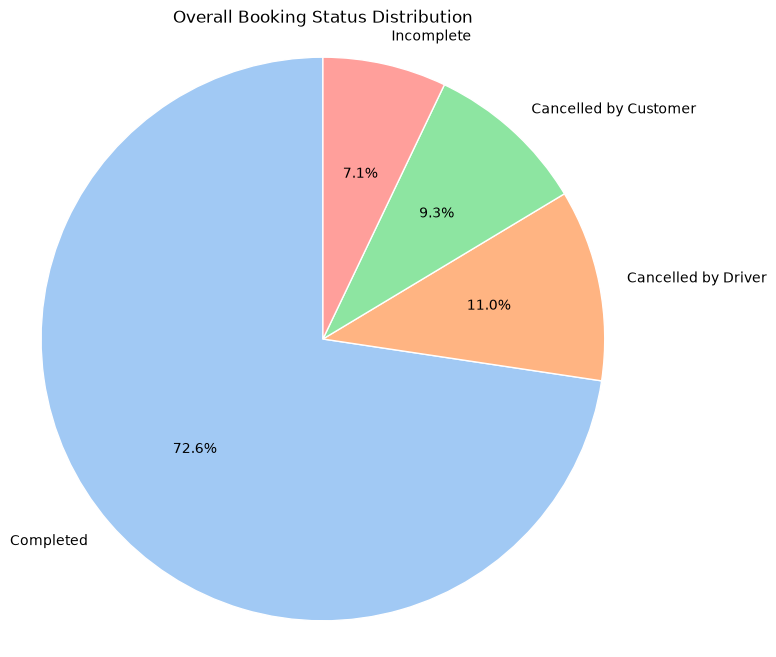

In [103]:
#OVERALL BOOKING STATUS AS PIE CHART
plt.figure(figsize=(8, 8))

status_counts = uber_df['Booking Status'].value_counts()

plt.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel'),
    wedgeprops={'edgecolor': 'white'}
)

plt.title('Overall Booking Status Distribution')
plt.axis('equal')
plt.show()


#### HEATMAPS

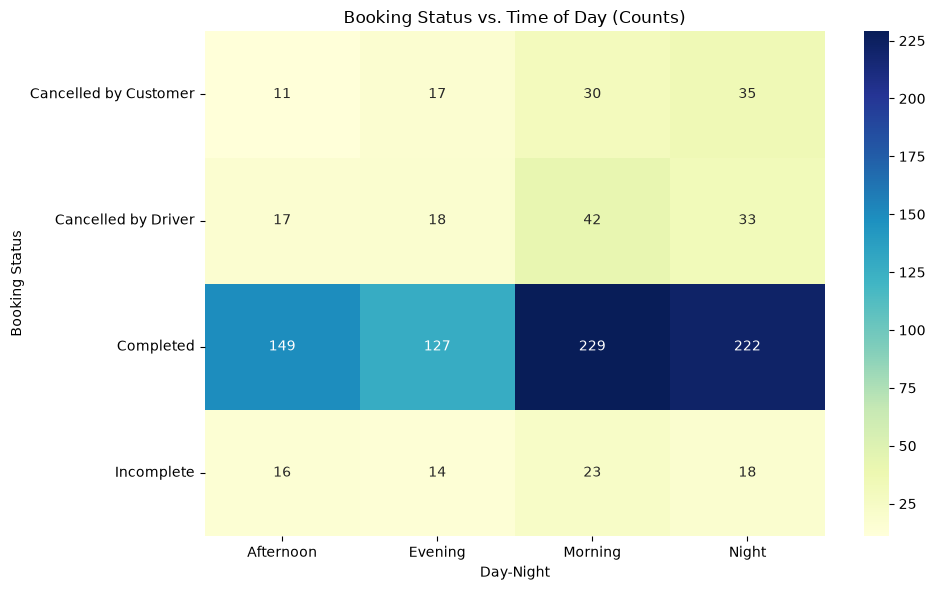

In [104]:
#Heatmap for Analyzing booking status vs. time of day

def get_heatmap_data(df, col1='Booking Status', col2='Day-Night'):
    return df.groupby([col1, col2]).size().unstack()

heatmap_data = get_heatmap_data(uber_df)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Booking Status vs. Time of Day (Counts)')
plt.tight_layout()
plt.show()

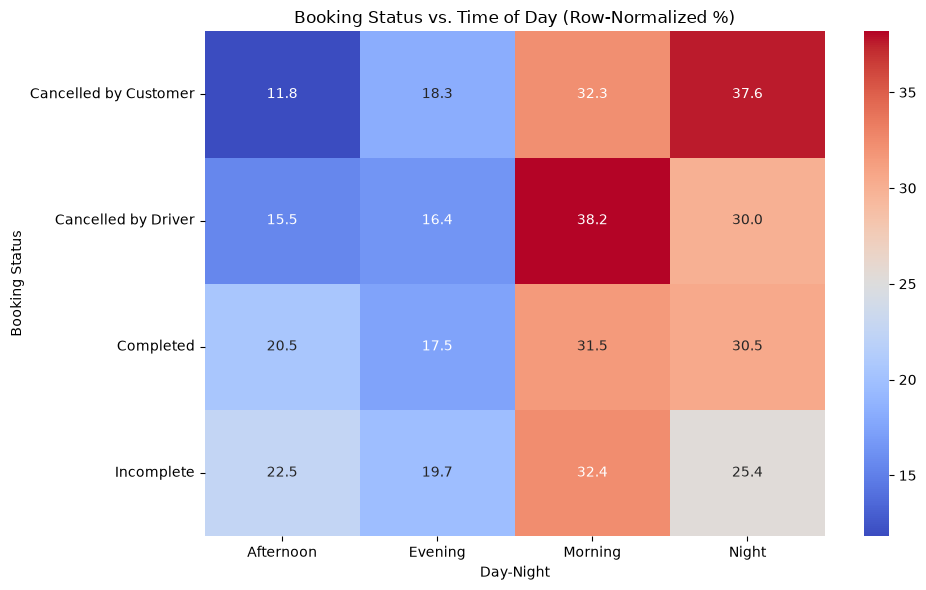

In [105]:
#NORMALIZED HEAT MAP 
row_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(row_pct, annot=True, cmap='coolwarm', fmt='.1f')
plt.title('Booking Status vs. Time of Day (Row-Normalized %)')
plt.tight_layout()
plt.show()

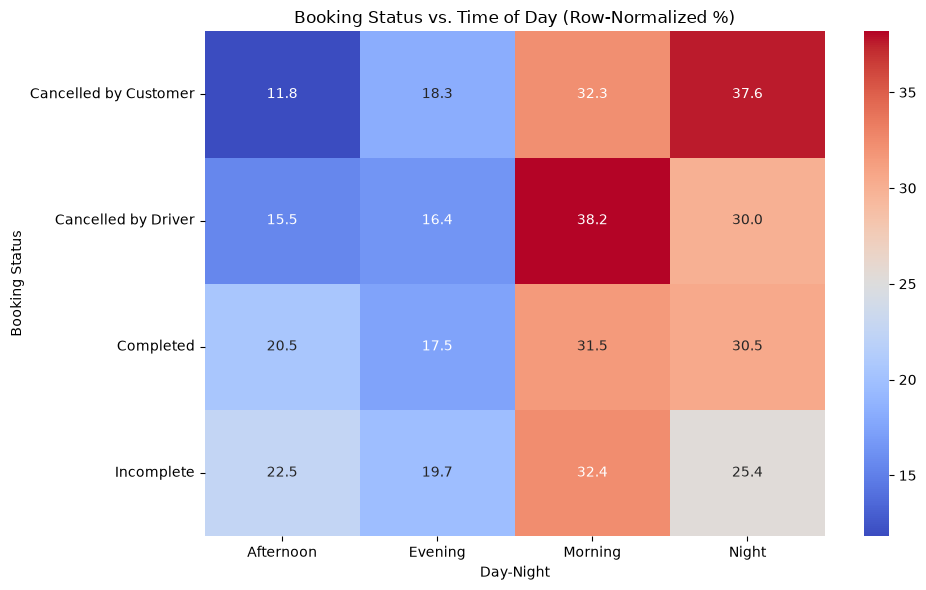

In [109]:
#Heatmap with custom annotation

row_pct = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(row_pct, annot=True, cmap='coolwarm', fmt='.1f')

plt.title('Booking Status vs. Time of Day (Row-Normalized %)')
plt.tight_layout()
plt.show()
